# Mathematical Engineering - Financial Engineering, FY 2024-2025
# Risk Management - Final Project: Fundamental Review Trading  - Group 2A



In [1]:
# IMPORT LIBRARIES

import numpy as np
import pandas as pd
import datetime as dt
import scipy.stats as stats
import matplotlib.pyplot as plt

from scipy.stats import norm

from utilities.FinalProject_utilities1 import (
    business_date_offset,
    date_series,
    extract_data,
    bootstrap,
    zero_rates,
    zeta_spread,
    swap_par_rate,
    portfolio_price_calculator,adjust_to_busday
)

from utilities.FinalProject_utilities2 import (
    capital,
    sensitivities_ir,
    sensitivities_cs
)

from utilities.FinalProject_utilities3 import (
    read_historical_data,
    daily_losses,
    weighted_hs_VAR,
    gauss_parametric_VAR,
    search_min,
    search_min_delta,
    regulatory_capital_MC,
    regulatory_capital_boot
)


In [2]:
# READ MARKET DATA, BOOTSTRAP, ZERO-RATES, ZETA-SPREADS

# Dates Set
start_date = dt.date(2016, 4, 7)

one_year = business_date_offset(start_date, 1) # One year from the starting date
ten_year = business_date_offset(start_date, 10) # Ten years from the starting date

first_year = date_series(start_date, one_year, 4) # Dates in the first year
other_year = date_series(start_date, ten_year, 1) # Dates in the next years

dates_set = first_year[:3] + other_year[1:]
dates_set = adjust_to_busday(dates_set) # Total dates set, adjusted to business days

# Rates Set and Yield to Maturity Set from Excel data
file_path = "TS_and_shocks.xlsx" # Change the path
data = extract_data(file_path)
rates_set = {'depos': data['depos_rates'], 'swaps': data['swaps_rates']}
ytm = data['ytm']

# Bootstrap
dates, discounts = bootstrap(dates_set, rates_set)

# Zero-Rates
ZR = zero_rates (dates, discounts)

# Zeta-Spreads
expiries = [2,3,5] # Bond market data for zs (rhs)
coupons = [0.01, 0.0125, 0.0175] # Bond market data for zs (rhs)
notionals = [40, 80, 160]*1000000 # Bond market data for zs (rhs)
ZS = zeta_spread(start_date, expiries, coupons, notionals, ytm, dates, discounts)


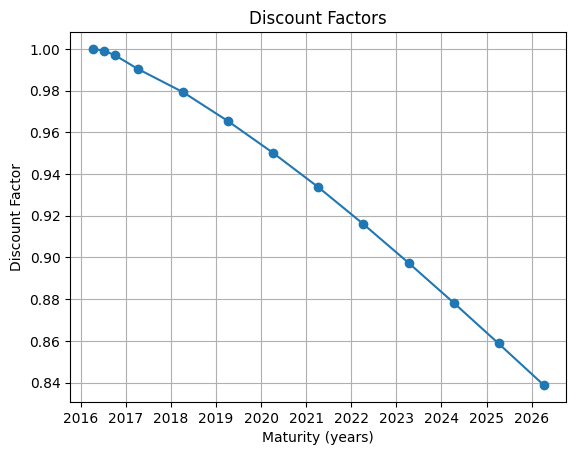

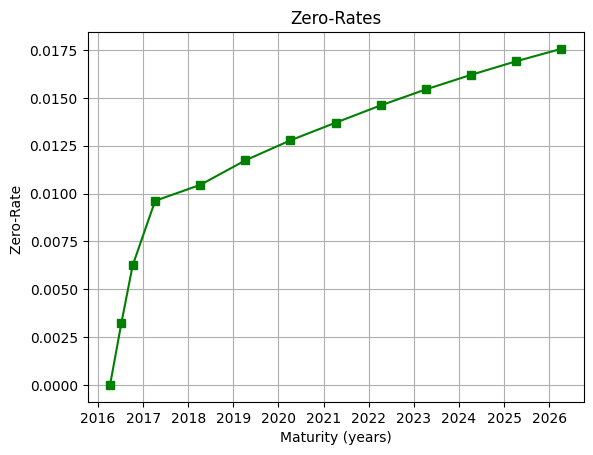

In [3]:
# PLOT THE CURVES

# Plot 1: Discount Factors
plt.figure()
plt.plot(dates_set[:13], discounts, marker='o')
plt.title("Discount Factors")
plt.xlabel("Maturity (years)")
plt.ylabel("Discount Factor")
plt.grid(True)

# Plot 2: Zero-Rates
plt.figure()
plt.plot(dates_set[:13], ZR, marker='s', color='green')
plt.title("Zero-Rates")
plt.xlabel("Maturity (years)")
plt.ylabel("Zero-Rate ")
plt.grid(True)

plt.show()


In [4]:
# PORTFOLIO PRICE TODAY (07/04/2016)

# Market data (in this order: 3 bonds, 1 IRS, 1 swaption)
notionals = [40e6, 80e6, 160e6, 280e6, 200e6]
maturities = [2,3,5,4,8]
coupons = [0.01, 0.0125, 0.0175, 0.010095]
sigma = 0.1 # Black volatility for swaption
expiry = 3 # Expiry of forward swap rate (forward start in years)
fwd_start_date = dates[5] # Forward start date

# Forward swap rate
SIR = swap_par_rate(dates, discounts, expiry, maturities[4], fwd_start_date)
K = SIR # ATM swaption

# Portfolio price
price = portfolio_price_calculator(notionals, maturities, coupons, start_date, fwd_start_date, ZS, dates, discounts, K, sigma, SIR)

print(f"Portfolio price today (07/04/16): ${price:,.0f}")


Portfolio price today (07/04/16): $283,981,211


In [5]:
# K STANDARDISED APPROACH

# Bump only the vertex until 5y, no effect on the next vertices (>= 10y). Vertex before 1y have no effect, but are considered.
idx_ir = [1, 2, 3, 4, 5, 7] # Indices of Zero-Rates curve to be bumped i.e. [3m, 6m, 1y, 2y, 3y, 5y]
weights_ir = [170, 170, 159, 133, 122, 106] # Pre-determined shocks
rho_ir = pd.read_excel('TS_and_shocks.xlsx', sheet_name=3, engine='openpyxl').iloc[5:11, 2:8].to_numpy() # Correlation

# Bump only the vertex until 5y, no effect on the next vertices (>= 10y). Vertex before 1y have no effect, but are NOT considered.
idx_cs = [1, 2] # Indices of Zeta-Spreads to be bumped [3y, 5y]
weights_cs = [300, 300] # Pre-determined shocks
rho_cs = pd.read_excel('TS_and_shocks.xlsx', sheet_name=4, engine='openpyxl').iloc[7:9, 4:6].to_numpy() # Correlation

# Sensitivities: interest rate and credit spread
s_ir = sensitivities_ir(notionals, maturities, coupons, start_date, fwd_start_date, ZS, dates, sigma, K, ZR, idx_ir, price)
s_cs = sensitivities_cs(notionals, maturities, coupons, start_date, fwd_start_date, ZS, dates, sigma, K, SIR, discounts, idx_cs, price)

# Capitals allocations
K_ir = capital(weights_ir, rho_ir, s_ir)
K_cs = capital(weights_cs, rho_cs, s_cs)

# Total Capital allocation
K_sa = K_ir + K_cs

print(f"Interest Rate Capital: ${K_ir:,.0f}")
print(f"Credit Spread Capital: ${K_cs:,.0f}")
print(f"Capital allocation with Standardised Approach: ${K_sa:,.0f}")


Interest Rate Capital: $15,430,064
Credit Spread Capital: $28,311,730
Capital allocation with Standardised Approach: $43,741,794


In [6]:
# PRINT THE SENSITIVITIES

# Interest rate
print("Sensitivities for each vertex (IR):")
print(f"{'Vertex':<15}{'Sensitivity':<15}")
for v, s in zip([0.25, 0.5, 1, 2, 3, 5], s_ir): print(f"{v:<15}{s:,.0f} $")

print("-" * 40)

# Credit spread
print("Sensitivities for each vertex (CS):")
print(f"{'Vertex':<15}{'Sensitivity':<15}")
for v, s in zip([3, 5], s_cs): print(f"{v:<15}{s:,.0f} $")


Sensitivities for each vertex (IR):
Vertex         Sensitivity    
0.25           0 $
0.5            0 $
1              -135 $
2              -8,129 $
3              -54,156 $
5              -73,730 $
----------------------------------------
Sensitivities for each vertex (CS):
Vertex         Sensitivity    
3              -23,707 $
5              -77,228 $


In [7]:
# K INTERNAL MODEL: SETTING

# Read historical data for both, stressed and not-stressed period. Use a unique matrix with all the risk-factors.
histo, stress_histo = read_historical_data(file_path)

# Compute daily losses for both, stressed and not-stressed period.
daily_loss, daily_sloss = daily_losses(s_ir, s_cs, histo, stress_histo)

# Set the parameters
alpha = 0.99 # Confidence level
Delta = 10 # Time horizon (in days)
Nsim = 10000 # Number of simulations for Bootstrap and MC methods
m = 3 # Multiplicator factor defined by regulator
l = 0.95 # Exponential decay for WHS


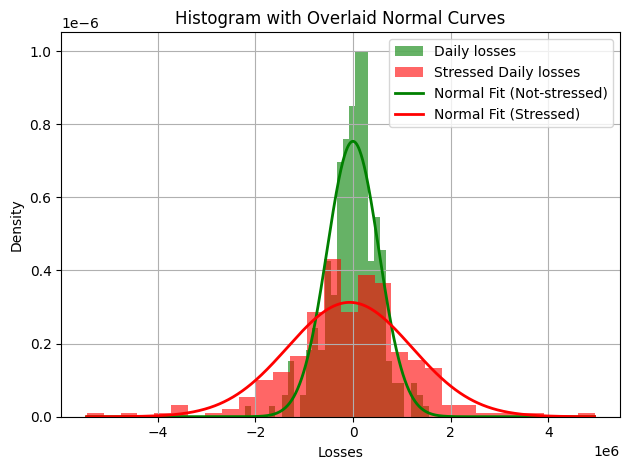

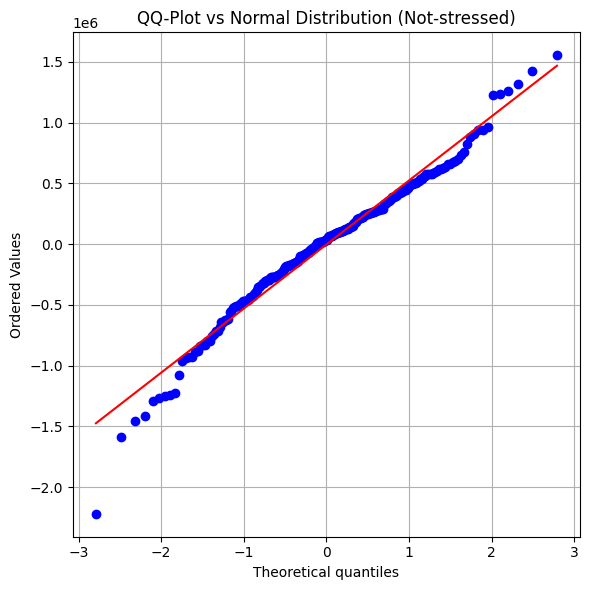

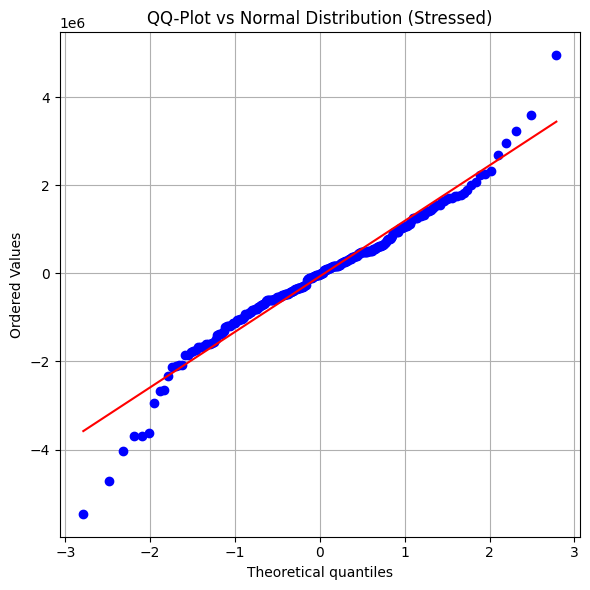

In [8]:
# GAUSSIANITY CHECK: DAILY LOSSES

# Mean and standard deviation (not-stressed and stressed scenarios)
mu = np.mean(daily_loss)
vol = np.std(daily_loss)

mu_s = np.mean(daily_sloss)
vol_s = np.std(daily_sloss)

# Histograms
plt.hist(daily_loss, bins=30, density=True, alpha=0.6, color='g', label='Daily losses')
plt.hist(daily_sloss, bins=30, density=True, alpha=0.6, color='r', label='Stressed Daily losses')

# Normal PDFs
x = np.linspace(min(np.min(daily_loss), np.min(daily_sloss)), max(np.max(daily_loss), np.max(daily_sloss)), 1000)
plt.plot(x, norm.pdf(x, mu, vol), 'g-', lw=2, label='Normal Fit (Not-stressed)')
plt.plot(x, norm.pdf(x, mu_s, vol_s), 'r-', lw=2, label='Normal Fit (Stressed)')

# Labels and legend
plt.title('Histogram with Overlaid Normal Curves')
plt.xlabel('Losses')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# QQ plot - Not-stressed scenario
plt.figure(figsize=(6, 6))
stats.probplot(daily_loss, dist="norm", plot=plt)
plt.title('QQ-Plot vs Normal Distribution (Not-stressed)')
plt.grid(True)
plt.tight_layout()
plt.show()

# QQ plot - Stressed scenario
plt.figure(figsize=(6, 6))
stats.probplot(daily_sloss, dist="norm", plot=plt)
plt.title('QQ-Plot vs Normal Distribution (Stressed)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
# K INTERNAL MODEL: STATISTICAL BOOTSTRAP

np.random.seed(100)

# Capital and Confidence Interval
K_old_sb, CI_sb = regulatory_capital_boot(alpha, Delta, daily_loss, daily_sloss, Nsim)

print(f"Capital allocation with Internal Model - Statistical Bootstrap: ${K_old_sb:,.0f}")
print(f"Confidence Interval Statistical Bootstrap: (${CI_sb[0]:,.0f}, ${CI_sb[1]:,.0f})")


Capital allocation with Internal Model - Statistical Bootstrap: $36,967,304
Confidence Interval Statistical Bootstrap: ($36,927,551, $37,007,056)


In [10]:
# K INTERNAL MODEL: PARAMETRIC GAUSSIAN

# VaR under normal market conditions and the Stressed VaR using stress-scenario data, via Parametric Gaussian.
Var = gauss_parametric_VAR(alpha, Delta, daily_loss)
sVar = gauss_parametric_VAR(alpha, Delta, daily_sloss)

K_old_gauss = m*(Var+sVar)

print(f"VaR - Parametric Gaussian: ${Var:,.0f}")
print(f"sVaR - Parametric Gaussian: ${sVar:,.0f}")
print(f"Capital allocation with Internal Model - Parametric Gaussian: ${K_old_gauss:,.0f}")


VaR - Parametric Gaussian: $3,878,509
sVaR - Parametric Gaussian: $8,706,072
Capital allocation with Internal Model - Parametric Gaussian: $37,753,742


In [11]:
# K INTERNAL MODEL: GAUSSIAN MONTECARLO

np.random.seed(100)

# Capital and Confidence Interval
K_old_mc, CI_mc = regulatory_capital_MC(alpha, Delta, histo, stress_histo, s_ir, s_cs, Nsim)

print(f"Capital allocation with Internal Model - Gaussian Monte-Carlo: ${K_old_mc:,.0f}")
print(f"Confidence Interval Gaussian Monte-Carlo: (${CI_mc[0]:,.0f}, ${CI_mc[1]:,.0f})")


Capital allocation with Internal Model - Gaussian Monte-Carlo: $37,721,091
Confidence Interval Gaussian Monte-Carlo: ($37,680,741, $37,761,442)


In [12]:
# K INTERNAL MODEL: WEIGHTED HISTORICAL SIMULATION

# VaR under normal market conditions and the Stressed VaR using stress-scenario data, via WHS.
Var = weighted_hs_VAR (alpha, Delta, daily_loss, l)
sVar = weighted_hs_VAR (alpha, Delta, daily_sloss, l)

K_old_whs = m*(Var+sVar)

print(f"VaR - Weighted Historical Simulation: ${Var:,.0f}")
print(f"sVaR - Weighted Historical Simulation: ${sVar:,.0f}")
print(f"Capital allocation with Internal Model - Weighted Historical Simulation: ${K_old_whs:,.0f}")


VaR - Weighted Historical Simulation: $3,858,348
sVaR - Weighted Historical Simulation: $9,719,731
Capital allocation with Internal Model - Weighted Historical Simulation: $40,734,239


In [13]:
# ALPHA & DELTA TO MINIMIZE THE CAPITAL DIFFERENCE: SETTING

# Confidence levels and VaR Holding Periods
alphas = np.arange(0.9, 0.991, 0.0001)
deltas = np.arange(1, 21)

# VaR and sVar as functions of alpha and Delta
Var = lambda alpha, Delta: weighted_hs_VAR(alpha, Delta, daily_loss, l)
sVar = lambda alpha, Delta: weighted_hs_VAR(alpha, Delta, daily_sloss,l )

# Error function
f = lambda alpha, Delta: abs(m * (Var(alpha, Delta) + sVar(alpha, Delta)) - K_sa)

# Starting min: guarantees to go in the "if condition" in the search_min function
x_min = np.inf


In [14]:
# GLOBAL MINIMUM PAIR

# Optimal pair
[diff_min, alpha_min, delta_min, x] = search_min (deltas, alphas, f, x_min)

print(f"Capitals Difference: ${diff_min:,.0f}")
print(f"Optimal Alpha: {alpha_min:,.4f}")
print(f"Optimal Delta: {delta_min}")


Capitals Difference: $424,042
Optimal Alpha: 0.9882
Optimal Delta: 13


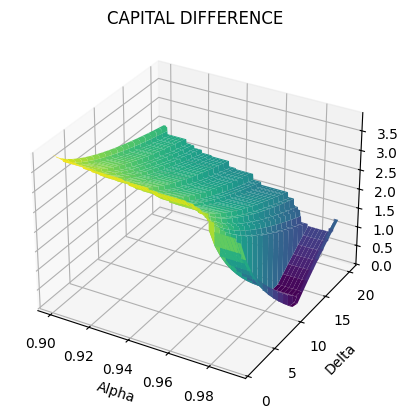

In [15]:
# PLOT THE SURFACE

X1, X2 = np.meshgrid(alphas, deltas)
fig = plt.figure(5)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, x, cmap='viridis')
ax.set_xlabel('Alpha')
ax.set_ylabel('Delta')
plt.title('CAPITAL DIFFERENCE')
plt.show()


In [16]:
# ALPHA AS DELTA FUNCTION

# Optimal alpha for each delta
alpha_star = search_min_delta (deltas, alphas, f)

print("Optimal alpha for each Delta:")
print(f"{'Delta':<15}{'Alpha':<15}")
for d, a in zip(deltas, alpha_star): print(f"{d:<15}{a:,.4f}")


Optimal alpha for each Delta:
Delta          Alpha          
1              0.9887
2              0.9887
3              0.9887
4              0.9887
5              0.9887
6              0.9887
7              0.9887
8              0.9887
9              0.9887
10             0.9887
11             0.9887
12             0.9887
13             0.9882
14             0.9759
15             0.9759
16             0.9759
17             0.9759
18             0.9758
19             0.9758
20             0.9758
